# Trabalho Computacional 01 — Atividade 02: Incerteza na realimentação

Este notebook estende a Atividade 01 sem alterar seu modelo físico, parâmetros, ponto de equilíbrio, PID ou critérios básicos. O único elemento novo é a incerteza na medição usada pelo controlador.

## 1. Objetivo

Adicionar ruído normal de média zero à medição da posição, reavaliar probabilisticamente a região de estabilidade em $\epsilon$ e, para $\epsilon=0{,}01x_0$, estudar a robustez em função do desvio-padrão `sd`.

## 2. Modelo herdado da Atividade 01

São preservados

$$L(x)=\frac{k}{x},\quad f_m(i,x)=\frac{ki^2}{2x^2},\quad Bl(i,x)=\frac{ki}{2x^2},$$

$$\dot i=-\frac{R}{L(x)}i-\frac{Bl(i,x)}{L(x)}v+\frac{u}{L(x)},\quad
\dot x=v,\quad \dot v=g-\frac{f_m(i,x)}m.$$

Também são fixados os resultados validados anteriormente:

$$i_0=1{,}260780151\ \mathrm A,\quad u_0=13{,}868581664\ \mathrm V,$$

$$K_p=2493{,}764852,\quad K_i=1643{,}309785,\quad K_d=32{,}835976.$$

Os valores são recalculados abaixo para manter o notebook autocontido.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import display, Markdown

m, g, k, R = 0.073, 9.81, 6.51e-5, 11.0
x0, v0, I_MAX = 8.5e-3, 0.0, 2.0
Kp, Ki, Kd = 2493.764852, 1643.309785, 32.835976
i0 = x0*np.sqrt(2*m*g/k)
u0 = R*i0

def L(x): return k/x
def fm(i, x): return k*i**2/(2*x**2)
def Bl(i, x): return k*i/(2*x**2)

print(f'i0 = {i0:.9f} A')
print(f'u0 = {u0:.9f} V')
print(f'PID: Kp={Kp:.6f}, Ki={Ki:.6f}, Kd={Kd:.6f}')
plt.rcParams.update({'figure.figsize':(10,4), 'axes.grid':True})

i0 = 1.260780151 A
u0 = 13.868581664 V
PID: Kp=2493.764852, Ki=1643.309785, Kd=32.835976


## 3. Modelo de incerteza da medição

A posição física permanece $x_{real}=x$. O sensor fornece

$$x_{medido}=x_{real}+n,\qquad n\sim\mathcal N(0,sd^2),$$

e o controlador utiliza

$$e_m=x_{medido}-x_0=x+n-x_0.$$

Assim, `x_real`, `x_medido`, `ruido` e `erro_medido` são grandezas distintas. O ruído não é somado à dinâmica mecânica.

O caso nominal desta atividade é $sd=0{,}04x_0$.

## 4. Representação com medição ruidosa

Os estados continuam

$$y=\begin{bmatrix}i&x&v&E\end{bmatrix}^{T},$$

com

$$\dot E=e_m,$$

e

$$u=u_0+K_pe_m+K_iE+K_d\dot e_m.$$

Como $\dot e_m=v+\dot n$, diferenciar diretamente amostras independentes amplificaria excessivamente o ruído. Nesta implementação, somente o caminho derivativo recebe uma versão filtrada $n_f$ do ruído, obtida por um filtro exponencial de primeira ordem com $\tau_f=0{,}10$ s:

$$n_f[j]=\alpha n_f[j-1]+(1-\alpha)n[j],\qquad \alpha=e^{-\Delta t/\tau_f},$$

$$\dot e_{m,f}=v+\frac{d n_f}{dt}.$$

Os termos proporcional e integral continuam usando o erro medido bruto $e_m$. O ruído é uma entrada exógena, não um novo estado do levitador.

## 5. Implementação da simulação com ruído

Para compatibilidade com `solve_ivp`, todas as amostras são geradas **antes** da integração numa grade fixa de medição ($\Delta t=0{,}05$ s). Durante as avaliações adaptativas, `numpy.interp` devolve sempre o mesmo sinal. Logo, uma `seed` identifica univocamente uma realização.

Não se aplica `clip` à corrente nem à tensão. Uma violação de 2 A permanece visível e invalida a realização.

In [2]:
NOISE_DT = 0.05       # s
FILTER_TAU = 0.10     # s

def generate_noise(sd, seed, t_final, dt=NOISE_DT, tau=FILTER_TAU):
    grid = np.arange(0.0, t_final + 0.5*dt, dt)
    noise = np.random.default_rng(seed).normal(0.0, sd, grid.size)
    filtered = np.empty_like(noise)
    filtered[0] = noise[0]
    alpha = np.exp(-dt/tau)
    for j in range(1, grid.size):
        filtered[j] = alpha*filtered[j-1] + (1-alpha)*noise[j]
    filtered_derivative = np.gradient(filtered, dt)
    return grid, noise, filtered, filtered_derivative

def simulate_with_noise(Kp, Ki, Kd, epsilon, sd, seed, t_final=3.0, n_points=601):
    if x0 + epsilon <= 0:
        raise ValueError('A condição inicial exige x0 + epsilon > 0.')
    noise_t, noise, noise_filtered, noise_derivative = generate_noise(sd, seed, t_final)

    def signals(t):
        n = np.interp(t, noise_t, noise)
        dn_f = np.interp(t, noise_t, noise_derivative)
        return n, dn_f

    def rhs(t, y):
        i, x, v, E = y
        n, dn_f = signals(t)
        measured_error = x + n - x0
        derivative_error = v + dn_f
        u = u0 + Kp*measured_error + Ki*E + Kd*derivative_error
        return [(-R*i-Bl(i,x)*v+u)/L(x), v, g-fm(i,x)/m, measured_error]

    def minimum_gap_event(t, y): return y[1] - 1e-6
    minimum_gap_event.terminal = True
    minimum_gap_event.direction = -1
    t_eval = np.linspace(0.0, t_final, n_points)
    sol = solve_ivp(rhs, (0,t_final), [i0,x0+epsilon,v0,0.0],
                    t_eval=t_eval, events=minimum_gap_event,
                    rtol=1e-6, atol=1e-8, max_step=0.02)
    i, x, v, E = sol.y
    n = np.interp(sol.t, noise_t, noise)
    dn_f = np.interp(sol.t, noise_t, noise_derivative)
    x_measured = x + n
    measured_error = x_measured - x0
    voltage = u0 + Kp*measured_error + Ki*E + Kd*(v+dn_f)
    return {'solution':sol, 'tempo':sol.t, 'x_real':x, 'x_medido':x_measured,
            'ruido':n, 'erro_medido':measured_error, 'velocidade':v,
            'corrente':i, 'tensao':voltage, 'E':E, 'epsilon':epsilon,
            'sd':sd, 'seed':seed, 'completed':sol.success and sol.t.size==t_eval.size}


## 6. Demonstração para $sd=0{,}04x_0$

Usam-se a perturbação de 1% da Atividade 01 e uma seed fixa. Esta realização ilustra os sinais, mas não é usada isoladamente para concluir estabilidade.

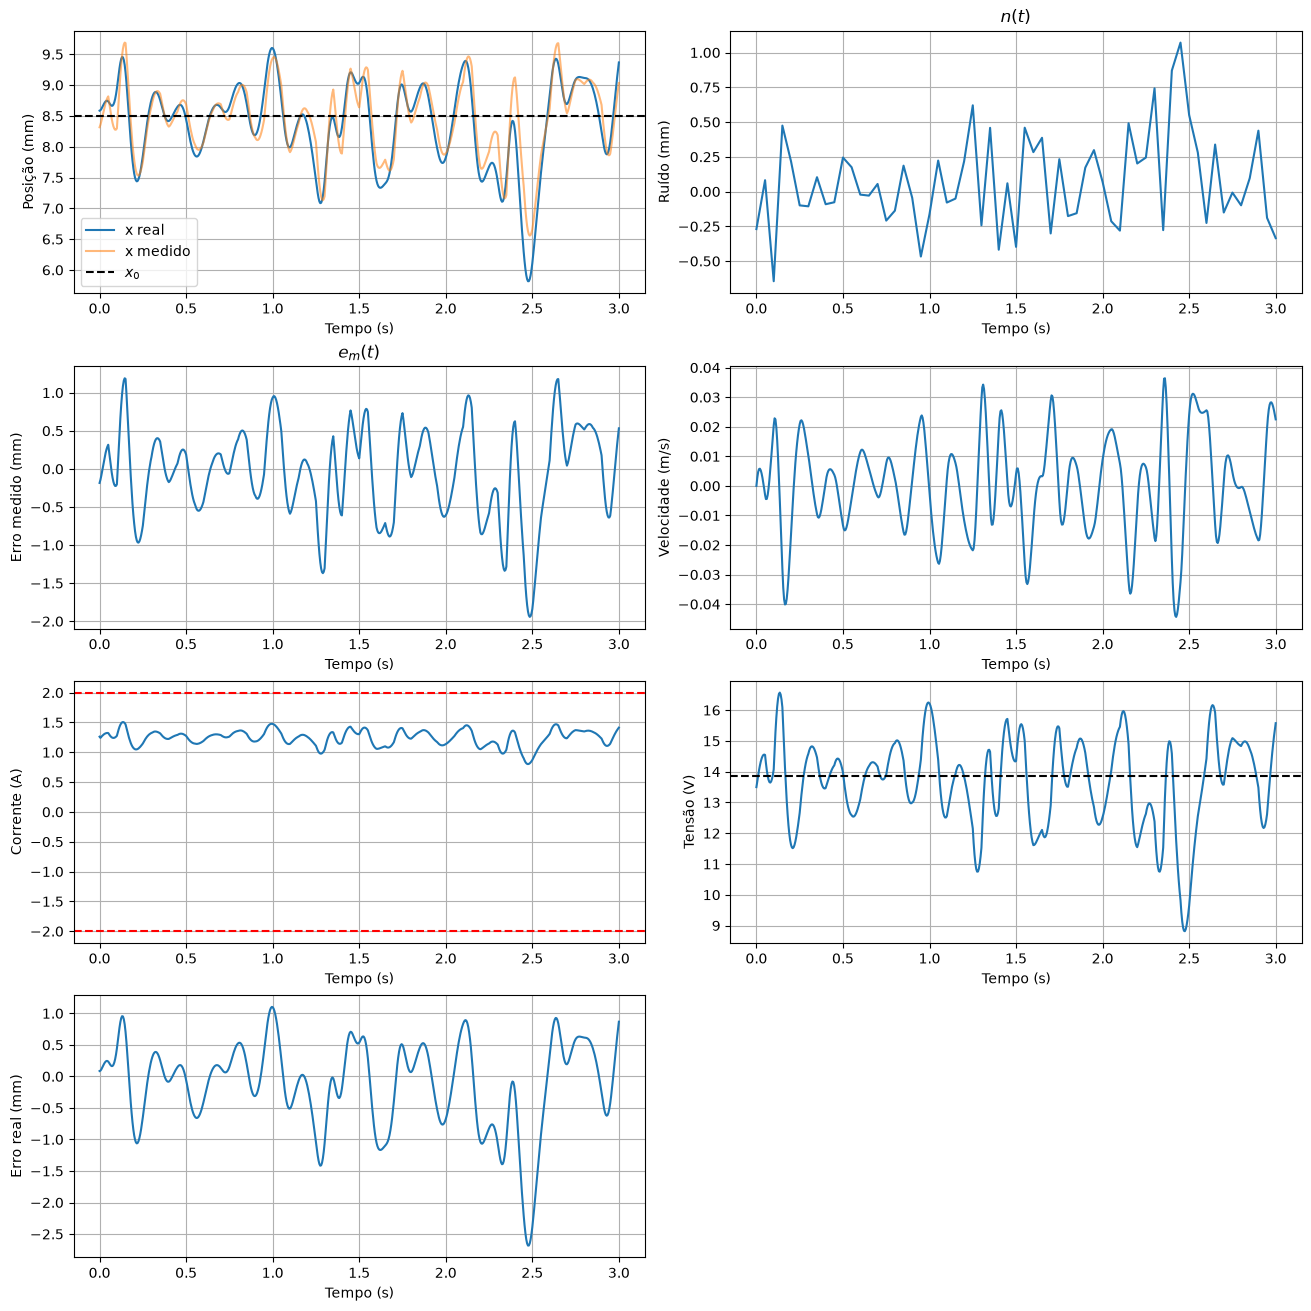

sd=3.400000e-04 m; epsilon=8.500000e-05 m; seed=2026
max |i|=1.506545 A


In [3]:
sd_nominal = 0.04*x0
epsilon_demo = 0.01*x0
demo_seed = 2026
demo = simulate_with_noise(Kp,Ki,Kd,epsilon_demo,sd_nominal,demo_seed,t_final=3.0)

fig, ax = plt.subplots(4,2,figsize=(13,13),constrained_layout=True)
t=demo['tempo']
ax[0,0].plot(t,1e3*demo['x_real'],label='x real'); ax[0,0].plot(t,1e3*demo['x_medido'],alpha=.55,label='x medido')
ax[0,0].axhline(1e3*x0,color='k',ls='--',label='$x_0$'); ax[0,0].set(xlabel='Tempo (s)',ylabel='Posição (mm)'); ax[0,0].legend()
ax[0,1].plot(t,1e3*demo['ruido']); ax[0,1].set(xlabel='Tempo (s)',ylabel='Ruído (mm)',title='$n(t)$')
ax[1,0].plot(t,1e3*demo['erro_medido']); ax[1,0].set(xlabel='Tempo (s)',ylabel='Erro medido (mm)',title='$e_m(t)$')
ax[1,1].plot(t,demo['velocidade']); ax[1,1].set(xlabel='Tempo (s)',ylabel='Velocidade (m/s)')
ax[2,0].plot(t,demo['corrente']); ax[2,0].axhline(2,color='r',ls='--'); ax[2,0].axhline(-2,color='r',ls='--'); ax[2,0].set(xlabel='Tempo (s)',ylabel='Corrente (A)')
ax[2,1].plot(t,demo['tensao']); ax[2,1].axhline(u0,color='k',ls='--'); ax[2,1].set(xlabel='Tempo (s)',ylabel='Tensão (V)')
ax[3,0].plot(t,1e3*(demo['x_real']-x0)); ax[3,0].set(xlabel='Tempo (s)',ylabel='Erro real (mm)')
ax[3,1].axis('off'); plt.show()
print(f'sd={sd_nominal:.6e} m; epsilon={epsilon_demo:.6e} m; seed={demo_seed}')
print(f'max |i|={np.max(np.abs(demo["corrente"])):.6f} A')

## 7. Critério de estabilidade

Mantêm-se os limites da Atividade 01: domínio físico, valores finitos, integração completa, $\max|i|\leq2$ A, erro de posição real de $10^{-5}$ m e velocidade de $10^{-4}$ m/s.

Com ruído persistente, valores instantâneos finais dependem arbitrariamente da última amostra. A única adaptação é avaliar a **média na janela final de 0,5 s** da posição real e da velocidade. As tolerâncias numéricas não são relaxadas. Essa escolha testa convergência média sem usar a posição medida contaminada.

In [4]:
POSITION_TOL, VELOCITY_TOL, FINAL_WINDOW = 1e-5, 1e-4, 0.5
PROBABILITY_THRESHOLD = 0.95
SEEDS = np.arange(30, dtype=int) + 1000

def stability_metrics(result):
    arrays=[result[k] for k in ('x_real','x_medido','ruido','erro_medido','velocidade','corrente','tensao')]
    finite=all(np.all(np.isfinite(a)) for a in arrays)
    tail=result['tempo'] >= result['tempo'][-1]-FINAL_WINDOW if result['tempo'].size else np.array([],bool)
    mean_error=abs(np.mean(result['x_real'][tail]-x0)) if finite and np.any(tail) else np.inf
    mean_velocity=abs(np.mean(result['velocidade'][tail])) if finite and np.any(tail) else np.inf
    max_current=np.max(np.abs(result['corrente'])) if finite else np.inf
    positive=finite and np.min(result['x_real'])>0
    stable=bool(result['completed'] and finite and positive and max_current<=I_MAX
                and mean_error<=POSITION_TOL and mean_velocity<=VELOCITY_TOL)
    return {'stable':stable,'max_abs_current':max_current,'mean_final_position_error':mean_error,
            'mean_final_velocity':mean_velocity,'positive_position':positive,'completed':result['completed']}

def evaluate_stability_probability(epsilon, sd, seeds=SEEDS, t_final=3.0):
    rows=[]
    for seed in seeds:
        if x0+epsilon<=0:
            metrics={'stable':False,'max_abs_current':np.inf,'mean_final_position_error':np.inf,'mean_final_velocity':np.inf}
        else:
            metrics=stability_metrics(simulate_with_noise(Kp,Ki,Kd,epsilon,sd,int(seed),t_final))
        rows.append(metrics)
    frame=pd.DataFrame(rows)
    return {'epsilon':epsilon,'epsilon_percent':100*epsilon/x0,'sd':sd,'sd_percent':100*sd/x0,
            'stable_runs':int(frame['stable'].sum()),'total_runs':len(frame),
            'stability_probability':frame['stable'].mean(),
            'mean_max_current':frame['max_abs_current'].mean(),
            'worst_max_current':frame['max_abs_current'].max(),
            'belongs_to_stable_region':bool(frame['stable'].mean()>=PROBABILITY_THRESHOLD)}

demo_metrics=stability_metrics(demo)
display(pd.Series(demo_metrics,name='Realização demonstrativa').to_frame())
print(f'Critério probabilístico da região: P(estável) >= {PROBABILITY_THRESHOLD:.2f}, com {len(SEEDS)} seeds fixas.')

,Realização demonstrativa
stable,False
max_abs_current,1.506545
mean_final_position_error,0.000058
mean_final_velocity,0.006676
positive_position,True
completed,True


Critério probabilístico da região: P(estável) >= 0.95, com 30 seeds fixas.


## 8. Reavaliação da faixa de $\epsilon$

Com $sd=0{,}04x_0$, cada perturbação é simulada com as mesmas 30 seeds. A grade inclui a faixa determinística anterior e pontos externos. Se nenhum ponto alcançar 95%, o resultado correto é declarar que não foi identificada uma faixa probabilisticamente estável — não fabricar fronteiras.

In [5]:
epsilon_percentages=np.array([-80,-70,-60,-50,-40,-20,0,10,20,30,40,50,60],float)
epsilon_table=pd.DataFrame([evaluate_stability_probability(p/100*x0,sd_nominal) for p in epsilon_percentages])
display(epsilon_table[['epsilon','epsilon_percent','stable_runs','total_runs','stability_probability','worst_max_current','belongs_to_stable_region']].style.format({
    'epsilon':'{:.7f}','epsilon_percent':'{:.1f}','stability_probability':'{:.3f}','worst_max_current':'{:.4f}'}))

accepted=epsilon_table[epsilon_table['belongs_to_stable_region']]
if accepted.empty:
    epsilon_min_noise=epsilon_max_noise=np.nan
    print('Nenhum epsilon da grade atingiu P(estável) >= 0,95; não há fronteiras a refinar sob o critério herdado.')
else:
    epsilon_min_noise=accepted['epsilon'].min(); epsilon_max_noise=accepted['epsilon'].max()
    print(f'Faixa identificada na grade: {epsilon_min_noise:.6e} a {epsilon_max_noise:.6e} m')

,epsilon,epsilon_percent,stable_runs,total_runs,stability_probability,worst_max_current,belongs_to_stable_region
0,-0.0068000,-80.0,0,30,0.000,1.2608,False
1,-0.0059500,-70.0,0,30,0.000,1.7221,False
2,-0.0051000,-60.0,0,30,0.000,1.8283,False
3,-0.0042500,-50.0,0,30,0.000,1.8159,False
4,-0.0034000,-40.0,0,30,0.000,1.8120,False
5,-0.0017000,-20.0,0,30,0.000,1.8037,False
6,0.0000000,0.0,0,30,0.000,1.7938,False
7,0.0008500,10.0,0,30,0.000,1.7882,False
8,0.0017000,20.0,0,30,0.000,1.7821,False
9,0.0025500,30.0,0,30,0.000,1.9046,False


Nenhum epsilon da grade atingiu P(estável) >= 0,95; não há fronteiras a refinar sob o critério herdado.


## 9. Estabilidade em função de `sd`

Fixa-se $\epsilon=0{,}01x_0$. A grade é mais detalhada perto de zero porque o critério herdado é exigente para ruído persistente. São usadas as mesmas 30 seeds em todos os níveis.

In [6]:
sd_percentages=np.array([0,0.1,0.25,0.5,0.75,1,2,3,4,5,6,8,10],float)
sd_table=pd.DataFrame([evaluate_stability_probability(epsilon_demo,p/100*x0) for p in sd_percentages])
display(sd_table[['sd','sd_percent','stable_runs','total_runs','stability_probability','mean_max_current','worst_max_current','belongs_to_stable_region']].style.format({
    'sd':'{:.7e}','sd_percent':'{:.2f}','stability_probability':'{:.3f}','mean_max_current':'{:.4f}','worst_max_current':'{:.4f}'}))

,sd,sd_percent,stable_runs,total_runs,stability_probability,mean_max_current,worst_max_current,belongs_to_stable_region
0,0.0000000e+00,0.00,30,30,1.000,1.2793,1.2793,True
1,8.5000000e-06,0.10,28,30,0.933,1.2791,1.2815,False
2,2.1250000e-05,0.25,10,30,0.333,1.2829,1.2923,False
3,4.2500000e-05,0.50,2,30,0.067,1.3036,1.3239,False
4,6.3750000e-05,0.75,0,30,0.000,1.3253,1.3558,False
5,8.5000000e-05,1.00,0,30,0.000,1.3471,1.3878,False
6,1.7000000e-04,2.00,0,30,0.000,1.4355,1.5176,False
7,2.5500000e-04,3.00,0,30,0.000,1.5254,1.6533,False
8,3.4000000e-04,4.00,0,30,0.000,1.6169,1.7933,False
9,4.2500000e-04,5.00,0,30,0.000,1.7100,1.9374,False


## 10. Visualização dos resultados

O primeiro gráfico mostra a probabilidade em função de `sd`; o segundo mostra a reavaliação em $\epsilon$. A linha de 95% é uma escolha metodológica explicitada, não um valor fornecido pelo professor.

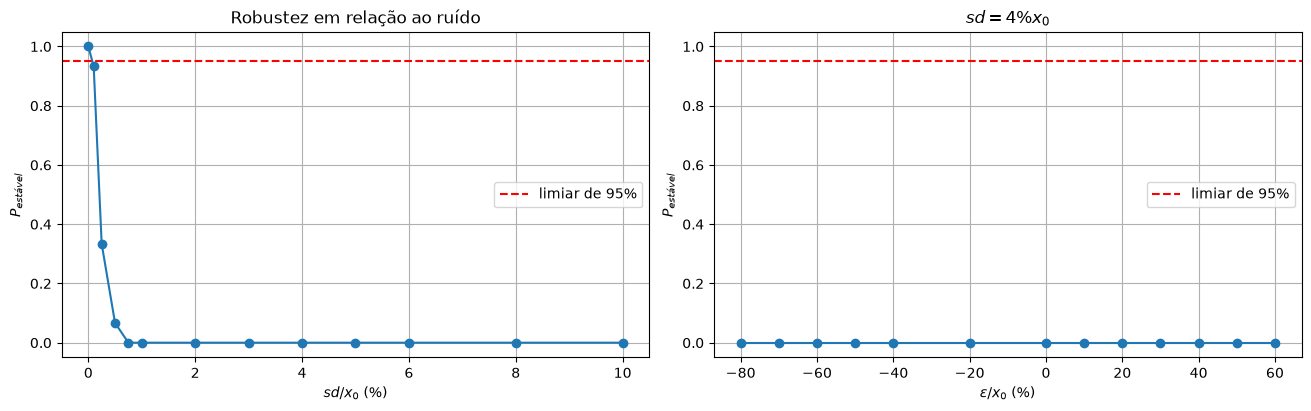

Transição observada entre 0.00% e 0.10% de x0.


In [7]:
fig,ax=plt.subplots(1,2,figsize=(13,4),constrained_layout=True)
ax[0].plot(sd_table['sd_percent'],sd_table['stability_probability'],'o-')
ax[0].axhline(PROBABILITY_THRESHOLD,color='r',ls='--',label='limiar de 95%')
ax[0].set(xlabel='$sd/x_0$ (%)',ylabel='$P_{estável}$',ylim=(-.05,1.05),title='Robustez em relação ao ruído'); ax[0].legend()
ax[1].plot(epsilon_table['epsilon_percent'],epsilon_table['stability_probability'],'o-')
ax[1].axhline(PROBABILITY_THRESHOLD,color='r',ls='--',label='limiar de 95%')
ax[1].set(xlabel=r'$\epsilon/x_0$ (%)',ylabel='$P_{estável}$',ylim=(-.05,1.05),title=r'$sd=4\%x_0$'); ax[1].legend()
plt.show()

passing_sd=sd_table[sd_table['belongs_to_stable_region']]
failing_sd=sd_table[~sd_table['belongs_to_stable_region']]
if not passing_sd.empty and not failing_sd.empty:
    last_sd_ok=passing_sd['sd_percent'].max(); first_sd_bad=failing_sd.loc[failing_sd['sd_percent']>last_sd_ok,'sd_percent'].min()
    print(f'Transição observada entre {last_sd_ok:.2f}% e {first_sd_bad:.2f}% de x0.')
else:
    last_sd_ok=np.nan
    print('A grade não apresentou uma transição completa que sustente um sd máximo.')

## 11. Comparação com a Atividade 01

A faixa sem ruído é apenas a referência já calculada. Para o caso ruidoso, valores ausentes (`NaN`) significam que nenhum ponto satisfaz o limiar probabilístico; não significam zero.

In [8]:
epsilon_min_clean_percent,epsilon_max_clean_percent=-69.940,39.434
comparison=pd.DataFrame({
    'Caso':['Sem ruído — Atividade 01','Com ruído — sd=4% x0'],
    'epsilon mínimo (%)':[epsilon_min_clean_percent,100*epsilon_min_noise/x0 if np.isfinite(epsilon_min_noise) else np.nan],
    'epsilon máximo (%)':[epsilon_max_clean_percent,100*epsilon_max_noise/x0 if np.isfinite(epsilon_max_noise) else np.nan]})
display(comparison.style.format({'epsilon mínimo (%)':'{:.3f}','epsilon máximo (%)':'{:.3f}'},na_rep='não identificada'))

,Caso,epsilon mínimo (%),epsilon máximo (%)
0,Sem ruído — Atividade 01,-69.940,39.434
1,Com ruído — sd=4% x0,não identificada,não identificada


## 12. Conclusões

A saída abaixo é construída automaticamente a partir das tabelas. A interpretação distingue estabilidade pelo critério rigoroso herdado de mero comportamento limitado sob ruído.

In [9]:
nominal_row=sd_table.loc[np.isclose(sd_table['sd_percent'],4.0)].iloc[0]
if np.isfinite(epsilon_min_noise):
    noisy_range=f'{epsilon_min_noise:.6e} a {epsilon_max_noise:.6e} m ({100*epsilon_min_noise/x0:.2f}% a {100*epsilon_max_noise/x0:.2f}%)'
else:
    noisy_range='não identificada para P(estável) >= 0,95 na grade analisada'
if np.isfinite(last_sd_ok):
    behavior=f'o limiar de 95% deixa de ser atendido entre {last_sd_ok:.2f}% e {first_sd_bad:.2f}% de x0'
else:
    behavior='não foi observada uma transição completa na grade'
summary=fr'''### Resumo automático da Atividade 02

**PID utilizado:** $K_p={Kp:.6f}$, $K_i={Ki:.6f}$, $K_d={Kd:.6f}$.

- Ruído nominal: $sd=0,04x_0={sd_nominal:.6e}$ m;
- perturbação demonstrativa: $\epsilon=0,01x_0={epsilon_demo:.6e}$ m;
- faixa sem ruído: −69,940% a +39,434% de $x_0$;
- faixa com ruído nominal: **{noisy_range}**;
- em $sd=4\%x_0$: {int(nominal_row.stable_runs)}/{int(nominal_row.total_runs)} realizações estáveis, $P={nominal_row.stability_probability:.3f}$;
- análise de `sd`: $\epsilon$ fixo em 1% de $x_0$, maior `sd` avaliado = {sd_percentages.max():.1f}% de $x_0$; {behavior}.

O ruído foi aplicado somente à medição. Sob ruído persistente, o critério herdado é avaliado pela média final da posição real e da velocidade, sem relaxar suas tolerâncias. Resultados que não atingem 95% são reportados como tais, mesmo quando as trajetórias permanecem limitadas.
'''
display(Markdown(summary))

### Resumo automático da Atividade 02

**PID utilizado:** $K_p=2493.764852$, $K_i=1643.309785$, $K_d=32.835976$.

- Ruído nominal: $sd=0,04x_0=3.400000e-04$ m;
- perturbação demonstrativa: $\epsilon=0,01x_0=8.500000e-05$ m;
- faixa sem ruído: −69,940% a +39,434% de $x_0$;
- faixa com ruído nominal: **não identificada para P(estável) >= 0,95 na grade analisada**;
- em $sd=4\%x_0$: 0/30 realizações estáveis, $P=0.000$;
- análise de `sd`: $\epsilon$ fixo em 1% de $x_0$, maior `sd` avaliado = 10.0% de $x_0$; o limiar de 95% deixa de ser atendido entre 0.00% e 0.10% de x0.

O ruído foi aplicado somente à medição. Sob ruído persistente, o critério herdado é avaliado pela média final da posição real e da velocidade, sem relaxar suas tolerâncias. Resultados que não atingem 95% são reportados como tais, mesmo quando as trajetórias permanecem limitadas.
